# 14 — LPT density: MAP estimation (dev notebook)

A clean, dev-oriented notebook for debugging the **minimization** itself: a joint MAP reconstruction of $(\Omega_c,\sigma_8)$ and the $\mathrm{MESH}^3$ initial-condition field on a 1LPT → spherical galaxy-overdensity mock (2 source planes, seed 0), minimized by a plain **optax adam** loop with the optimizer state carried across every step. No MCMC, and no Laplace machinery beyond a cheap 2×2 curvature of the conditioned potential. Headless: `uv run --no-sync papermill 14-LPT-MAP-Estimation.ipynb 14-LPT-MAP-Estimation.ipynb --cwd .`

The minimizer is a single continuous adam trajectory over `MAP_MAX_ITER` steps, and animation frames land at `N_SNAPSHOTS + 1` evenly spaced steps (frame 0 is the warm start): each frame saves the physical IC, the density lightcone and the Born kappa to `ic_evolution/`, `density_evolution/` and `kappa_evolution/` in `OUT_DIR`, so the advancing reconstruction can be animated offline without re-running the model.

## 1. Setup

The run shards over 8 fake CPU devices (`--xla_force_host_platform_device_count=8`, same trick as 05-Distributed-PM) on a `(4, 2)` mesh with the two source planes on the N axis; on a real machine drop the `XLA_FLAGS`/`JAX_PLATFORMS` lines in the setup cell. `jaxpm.distributed.normal_field` splits the seed per device, so the same `SEED` draws a different white-field realization than an unsharded run: each mode is self-consistent, but truth values (potential, S/N) are not comparable across the two.

In [ ]:
import os

os.environ["JAX_ENABLE_X64"] = "True"  # float32 => NaN/chaotic IC gradients
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

import time

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
import optax
from jax.scipy.special import ndtr, ndtri
from numpyro.handlers import condition, seed, trace
from numpyro.infer.util import initialize_model

import jax_fli as jfli
from jax_fli.initial import interpolate_initial_conditions

jax.config.update("jax_enable_x64", True)

# --- device mesh: the 2 source planes sit on the N axis (SPMD M/N convention) ---
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P

if jax.device_count() > 1:
    PDIMS = (jax.device_count(), 1)
    mesh = jax.make_mesh(PDIMS, ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
    sharding = NamedSharding(mesh, P("x", "y"))
else:
    PDIMS = (1, 1)
    mesh = None
    sharding = None

MESH = 64 
NSIDE = 64
PAINT_NSIDE = 32 
HALO_MULT = 1.0  # halo mass multiplier
MAP_MAX_ITER = 2000  # TOTAL optimizer steps. 
N_SNAPSHOTS = 10  # production: 10 — the minimizer is re-run N times, saving density+kappa after each
INIT_COSMO = {"Omega_c": 0.2607, "sigma8": 0.8102}  # physical starting cosmology (Planck18); None -> truth
INIT_NOISE = 0.02  # warm-start jitter on the free sites. Convergence budget scales with the
OPTIMIZE = "ic"  # "both" | "cosmo" | "ic" — which sites stay free under the potential
SEED = 0
OUT_DIR = "results"  # parquet outputs (gitignored run-data area)
INIT_COSMO = None # Only massmapping is done

print(
    f"jax {jax.__version__}  backend {jax.default_backend()}  x64 {jax.config.jax_enable_x64}"
    f"  MESH={MESH}  devices={jax.device_count()}  sharding={'none' if sharding is None else str(sharding.spec)}"
)

jax 0.11.1  backend cpu  x64 True  MESH=64  devices=1  sharding=none


## 2. Make model

1LPT → spherical galaxy overdensity, two source planes at $z=0.10, 0.17$, centered observer, $z\le0.2$.

In [ ]:
cosmo = jc.Planck18()
box = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, 0.2, (0.5, 0.5, 0.5)))

priors = {
    "Omega_c": jfli.infer.PreconditionnedUniform(0.1, 0.5),
    "sigma8": jfli.infer.PreconditionnedUniform(0.6, 1.0),
}
LOW, HIGH = jnp.array([0.1, 0.6]), jnp.array([0.5, 1.0])
# PreconditionnedUniform is uniform in PHYSICAL space, so base <-> physical is a probit map.
phys_of_base = lambda base: LOW + (HIGH - LOW) * ndtr(jnp.asarray(base))
base_of_phys = lambda phys: ndtri((jnp.asarray(phys) - LOW) / (HIGH - LOW))

halo_size = (int((MESH // PDIMS[0] )* HALO_MULT), int((MESH // PDIMS[1] ) * HALO_MULT))

config = jfli.ppl.Configurations(
    mesh_size=(MESH, MESH, MESH),
    box_size=box,
    halo_size=halo_size,  # ghost cells for the sharded stencil/FFT exchange (~5% of the 64^3 mesh)
    field_sharding=sharding,
    sim_mode="lpt",
    nbody_solver="BullFrog",  # inert in "lpt" mode
    t0=0.001,
    t1=1.0,
    lpt_order=1,
    number_of_shells=5,
    nb_steps=5,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    shell_spacing="a",
    time_stepping="D",
    min_width=1.0,
    lensing_output="density",
    map2alm_method="jax",
    min_redshift=0.001,
    max_redshift=0.2,
    n_integrate=8,
    nside=NSIDE,
    geometry="spherical",
    scheme="bilinear",
    observer_position=(0.5, 0.5, 0.5),
    paint_nside=PAINT_NSIDE,
    kernel_width_pixels=0.8,
    fiducial_cosmology=jc.Planck18,
    nz_shear=[0.10, 0.17],
    priors=priors,
    sigma_e=0.3,
    adjoint="checkpointed",
    checkpoints=2,
)
model = jfli.ppl.full_field_probmodel(config)

## 3. Trace it and show observable

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

wrote true_ic / truth_density_lightcone / truth_kappa to results
truth  Omega_c=0.1322  sigma8=0.8685   S/N per pixel ~ 22.9
truth lightcone (5, 49152)  truth kappa (2, 49152)


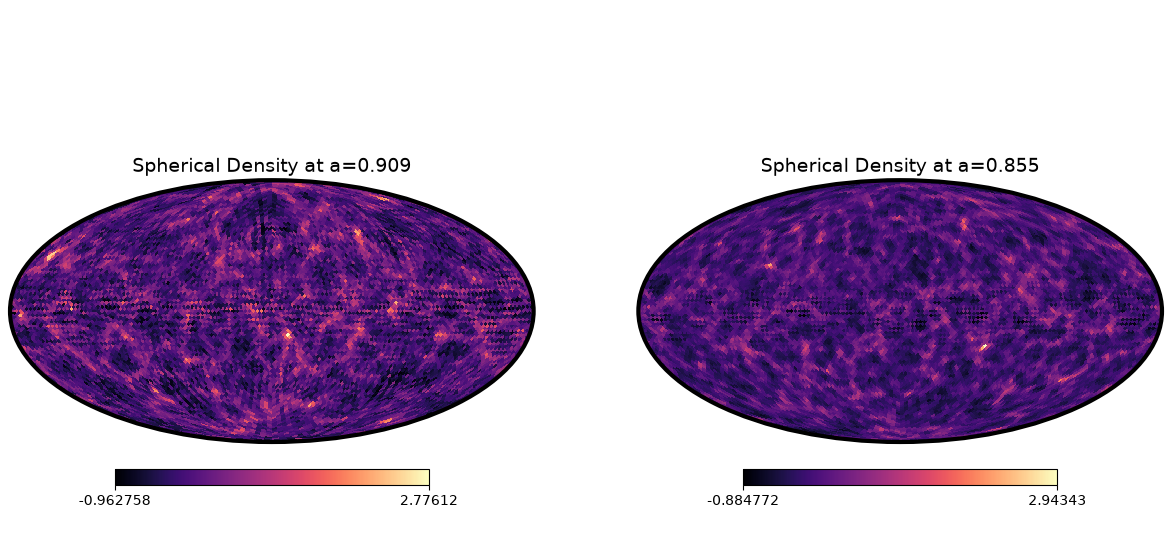

In [3]:
tr = trace(seed(model, SEED)).get_trace()

theta_truth_base = jnp.array([float(tr["Omega_c_base"]["value"]), float(tr["sigma8_base"]["value"])])
theta_truth = jnp.array([float(tr["Omega_c"]["value"]), float(tr["sigma8"]["value"])])
ic_truth_white = np.asarray(tr["initial_conditions"]["value"].array)
truth_cosmo = tr["cosmo"]["value"]

# One forward pass used for every prediction in this notebook — truth, init and snapshots. The
# kappa is Born-projected from the same lightcone the density likelihood sees; it is
# diagnostic-only (the likelihood is on the galaxy-overdensity observable).
forward = jfli.ppl.make_full_field_model(config)


def predict(cosmo, white):
    """(cosmo, white IC) -> (physical IC, density lightcone, Born kappa)."""
    ic = interpolate_initial_conditions(
        white,
        config.mesh_size,
        config.box_size,
        cosmo=cosmo,
        observer_position=config.observer_position,
        halo_size=config.halo_size,
        nside=config.nside,
        field_sharding=config.field_sharding,
    )
    _, lightcone = forward(cosmo, ic)
    kappa = jfli.born(
        cosmo,
        lightcone,
        nz_shear=config.nz_shear,
        min_z=config.min_redshift,
        max_z=config.max_redshift,
        n_integrate=config.n_integrate,
        quadrature=config.quadrature,
    )
    for name, arr in (("ic", ic.array), ("lightcone", lightcone.array), ("kappa", kappa.array)):
        n_bad = int(np.count_nonzero(~np.isfinite(np.asarray(jax.device_get(arr)))))
        if n_bad:
            raise ValueError(f"predict(): {name} contains {n_bad} non-finite values")
    return ic, lightcone, kappa


ic_truth, lightcone_truth, kappa_truth = predict(truth_cosmo, ic_truth_white)

# Save the truth stage to parquet. Catalog rows require the dynamic lightcone metadata columns;
# IC fields carry none, so fill them with zeros (same convention as sample2catalog).
os.makedirs(OUT_DIR, exist_ok=True)
ic_truth_cat = ic_truth.replace(
    name="true_ic",
    z_sources=jnp.zeros(ic_truth.array.shape[0]),
    comoving_centers=jnp.zeros(ic_truth.array.shape[0]),
    scale_factors=jnp.zeros(ic_truth.array.shape[0]),
    density_width=jnp.zeros(ic_truth.array.shape[0]),
)
jfli.io.Catalog(field=[ic_truth_cat], cosmology=[truth_cosmo]).to_parquet(os.path.join(OUT_DIR, "true_ic.parquet"))
jfli.io.Catalog(field=[lightcone_truth], cosmology=[truth_cosmo]).to_parquet(
    os.path.join(OUT_DIR, "truth_density_lightcone.parquet")
)
jfli.io.Catalog(field=[kappa_truth], cosmology=[truth_cosmo]).to_parquet(os.path.join(OUT_DIR, "truth_kappa.parquet"))
print(f"wrote true_ic / truth_density_lightcone / truth_kappa to {OUT_DIR}")

x_obs = jnp.stack([tr[f"observable_{i}"]["value"] for i in range(2)])
sig_obs = float(jnp.mean(tr["observable_0"]["fn"].scale))
snr = float(np.asarray(tr["observable_0"]["fn"].loc).std()) / sig_obs
print(f"truth  Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}   S/N per pixel ~ {snr:.1f}")
print(f"truth lightcone {np.asarray(lightcone_truth.array).shape}  truth kappa {np.asarray(kappa_truth.array).shape}")

x_obs_field = jfli.SphericalDensity.FromDensityMetadata(array=x_obs, field=tr["observable_meta_data"]["value"])
x_obs_field.show()

## 4. Condition on observable and choose the free sites

The two `observable_i` maps are always conditioned. `OPTIMIZE` then picks the remaining free sites: `"both"` keeps `Omega_c_base`, `sigma8_base` and the white `initial_conditions` free; `"cosmo"` fixes the IC at its init value; `"ic"` fixes the cosmology at `INIT_COSMO`.

In [4]:
# Starting point of the reconstruction: the chosen initial cosmology and the truth white IC
# (the jitter is applied to the free sites at warm-start time, in section 6).
if INIT_COSMO is None:
    init_theta_phys = theta_truth
    init_cosmo_base = theta_truth_base
else:
    init_theta_phys = jnp.array([float(INIT_COSMO["Omega_c"]), float(INIT_COSMO["sigma8"])])
    init_cosmo_base = base_of_phys(init_theta_phys)
init_cosmo = config.fiducial_cosmology(Omega_c=float(init_theta_phys[0]), sigma8=float(init_theta_phys[1]))
ic_init_white = jnp.asarray(ic_truth_white)

if OPTIMIZE == "cosmo":
    fixed = {"initial_conditions": ic_init_white}
elif OPTIMIZE == "ic":
    fixed = {"Omega_c_base": init_cosmo_base[0], "sigma8_base": init_cosmo_base[1]}
elif OPTIMIZE == "both":
    fixed = {}
else:
    raise ValueError(f"OPTIMIZE must be 'both', 'cosmo' or 'ic', got {OPTIMIZE!r}")

cond_model = condition(model, data={f"observable_{i}": x_obs[i] for i in range(2)} | fixed)
free_sites = [s for s in ("Omega_c_base", "sigma8_base", "initial_conditions") if s not in fixed]
print(f"OPTIMIZE={OPTIMIZE!r}  free sites: {free_sites}")
print(f"init  Omega_c={float(init_theta_phys[0]):.4f}  sigma8={float(init_theta_phys[1]):.4f}")

# Colour the init white IC at the init cosmology and save it (zero-filled lightcone metadata,
# same convention as sample2catalog).
ic_init = interpolate_initial_conditions(
    ic_init_white,
    config.mesh_size,
    config.box_size,
    cosmo=init_cosmo,
    observer_position=config.observer_position,
    halo_size=config.halo_size,
    nside=config.nside,
    field_sharding=config.field_sharding,
)
ic_init_cat = ic_init.replace(
    name="init_ic",
    z_sources=jnp.zeros(ic_init.array.shape[0]),
    comoving_centers=jnp.zeros(ic_init.array.shape[0]),
    scale_factors=jnp.zeros(ic_init.array.shape[0]),
    density_width=jnp.zeros(ic_init.array.shape[0]),
)
jfli.io.Catalog(field=[ic_init_cat], cosmology=[init_cosmo]).to_parquet(os.path.join(OUT_DIR, "init_ic.parquet"))
print(f"wrote init_ic to {OUT_DIR}")

OPTIMIZE='ic'  free sites: ['initial_conditions']
init  Omega_c=0.1322  sigma8=0.8685


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

wrote init_ic to results


## 5. Make potential

`potential_fn(position)` is the NumPyro negative log posterior over the free sites.

In [5]:
param_info, potential_fn, postprocess_fn, _ = initialize_model(jax.random.PRNGKey(0), cond_model, dynamic_args=False)
init_params = param_info.z  # numpyro >= 0.21 wraps the position in a ParamInfo namedtuple
print("free sites:", list(init_params.keys()))
assert set(init_params.keys()) == set(free_sites)

potential = lambda params: potential_fn(params)
vg = jax.jit(jax.value_and_grad(potential))

# Reference values per site: truth cosmology + truth white IC, restricted to the free sites.
site_truth = {
    "Omega_c_base": theta_truth_base[0],
    "sigma8_base": theta_truth_base[1],
    "initial_conditions": jnp.asarray(ic_truth_white),
}
truth_position = {s: site_truth[s] for s in free_sites}

val, g = jax.block_until_ready(vg(truth_position))
assert np.isfinite(float(val)) and all(np.all(np.isfinite(np.asarray(x))) for x in jax.tree.leaves(g))
print(f"potential(truth) = {float(val):.2f}   (finite gradient OK)")

free sites: ['initial_conditions']


potential(truth) = 117654.69   (finite gradient OK)


## 6. Minimize it in one continuous run with animation frames

Warm start at the `INIT_COSMO` cosmology with the truth white IC plus an `INIT_NOISE` jitter on every free site, so the reconstruction starts away from the truth. The minimiser is a plain **optax adam** loop — one `value_and_grad` per step and optimizer state carried across all `MAP_MAX_ITER` steps with no resets. Once the MAP basin is reached, adam at a fixed schedule overshoots along the flat directions, so the frames (and the final MAP) track the **best-so-far iterate** while the section-7 curve shows the raw trajectory alongside. `|grad|` at the returned point is the convergence gate. Animation frames at `N_SNAPSHOTS + 1` evenly spaced steps (frame 0 = warm start); each frame runs a full forward pass (`predict`, section 3) and saves the physical IC, the density lightcone and the Born kappa as `OUT_DIR/ic_evolution/ic_{frame}.parquet`, `OUT_DIR/density_evolution/lc_{frame}.parquet` and `OUT_DIR/kappa_evolution/kappa_{frame}.parquet`. Past the MAP the frames show the loss still improving while the field drifts from the truth — the overfitting drift of the report.

In [6]:
keys = jax.random.split(jax.random.PRNGKey(30), 3)
site_init = {
    "Omega_c_base": init_cosmo_base[0],
    "sigma8_base": init_cosmo_base[1],
    "initial_conditions": ic_init_white,
}
warm = {s: site_init[s] + INIT_NOISE * jax.random.normal(keys[i], site_init[s].shape) for i, s in enumerate(free_sites)}

# One continuous adam trajectory: optax state is carried across every step (no resets between
# snapshots) and the raw advancing iterate is kept -- no best-so-far tracking, so the frames show
# the true trajectory. Frame 0 is the warm start; the rest land on evenly spaced steps.
frames = np.linspace(0, MAP_MAX_ITER, N_SNAPSHOTS + 1).astype(int)
print(f"{MAP_MAX_ITER} continuous adam steps, frames at steps {frames.tolist()}")

from pathlib import Path

ic_path = os.path.join(OUT_DIR, "ic_evolution")
lc_path = os.path.join(OUT_DIR, "density_evolution")
kappa_path = os.path.join(OUT_DIR, "kappa_evolution")
for path, pattern in ((ic_path, "ic_*.parquet"), (lc_path, "lc_*.parquet"), (kappa_path, "kappa_*.parquet")):
    os.makedirs(path, exist_ok=True)
    for stale in Path(path).glob(pattern):  # a rerun must not mix frames from an older run
        stale.unlink()


def snapshot(position, frame, step, loss, raw=None):
    """Save the reconstruction at the current position: physical IC + density lightcone + Born kappa."""
    if "Omega_c_base" in free_sites:
        theta_run = phys_of_base(jnp.array([position["Omega_c_base"], position["sigma8_base"]]))
    else:
        theta_run = init_theta_phys
    white_run = position.get("initial_conditions", ic_init_white)
    cosmo_run = config.fiducial_cosmology(Omega_c=float(theta_run[0]), sigma8=float(theta_run[1]))
    ic_run, lc_run, kappa_run = predict(cosmo_run, white_run)
    mse_ic = float(((ic_run.array - ic_truth.array) ** 2).mean())
    mse_kappa = float(((kappa_run.array - kappa_truth.array) ** 2).mean())
    d_ic = position.get("initial_conditions")
    d_ic_norm = (
        float(jnp.sqrt(jnp.vdot(d_ic - warm["initial_conditions"], d_ic - warm["initial_conditions"]).real))
        if d_ic is not None
        else float("nan")
    )
    ic_cat = ic_run.replace(
        name=f"ic_{frame}",
        z_sources=jnp.zeros(ic_run.array.shape[0]),
        comoving_centers=jnp.zeros(ic_run.array.shape[0]),
        scale_factors=jnp.zeros(ic_run.array.shape[0]),
        density_width=jnp.zeros(ic_run.array.shape[0]),
    )
    ic_cat, lc_run, kappa_run = jax.device_get(ic_cat), jax.device_get(lc_run), jax.device_get(kappa_run)
    jfli.io.Catalog(field=[ic_cat], cosmology=[cosmo_run]).to_parquet(os.path.join(ic_path, f"ic_{frame}.parquet"))
    jfli.io.Catalog(field=[lc_run], cosmology=[cosmo_run]).to_parquet(os.path.join(lc_path, f"lc_{frame}.parquet"))
    jfli.io.Catalog(field=[kappa_run], cosmology=[cosmo_run]).to_parquet(os.path.join(kappa_path, f"kappa_{frame}.parquet"))
    label = "warm start" if frame == 0 else f"frame {frame}/{N_SNAPSHOTS}"
    raw_tag = "" if raw is None else f"  raw={raw:.4f}"
    print(
        f"{label} (step {step}):  loss={loss:.4f}{raw_tag}"
        f"  Omega_c={float(theta_run[0]):.4f}  sigma8={float(theta_run[1]):.4f}"
        f"  MSE(IC)={mse_ic:.3e}  MSE(kappa)={mse_kappa:.3e}"
        f"  |dIC|={d_ic_norm:.2f}",
        flush=True,
    )


losses, unorms = [], []
t0 = time.time()
position = warm
# Constant-lr adam goes unstable once it reaches the MAP basin (the raw iterate drifts away
# after ~400 steps; the chunked runs hid this by re-damping the moments at every reset). A
# cosine decay keeps the continuous trajectory converging and the frames parked at the MAP.
schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=MAP_MAX_ITER, alpha=0.1)
solver = optax.adam(learning_rate=schedule)
opt_state = solver.init(position)
val0, _ = vg(position)
best_f, best_params = float(val0), position  # best-so-far iterate; the state never resets, but
# adam at a fixed schedule overshoots along the flat directions once the MAP basin is reached,
# so the frames (and the final MAP) track the best point seen, like cadre's BestSoFarMinimiser.
snapshot(best_params, 0, 0, best_f)
for step in range(1, MAP_MAX_ITER + 1):
    val, grad = vg(position)
    updates, opt_state = solver.update(grad, opt_state, position)
    position = optax.apply_updates(position, updates)
    losses.append(float(val))  # objective at the start of the step
    unorms.append(float(jnp.sqrt(sum(jnp.vdot(u, u).real for u in jax.tree.leaves(updates)))))
    if losses[-1] < best_f:
        best_f, best_params = losses[-1], position
    if step in frames[1:]:
        snapshot(best_params, int(np.searchsorted(frames, step)), step, best_f, raw=losses[-1])

print(f"total {time.time() - t0:.1f}s")
print(f"tracked best objective = {best_f:.4f}   raw end-iterate objective = {losses[-1]:.4f}")

map_params = best_params
_, g_map = vg(map_params)
gnorm = float(jnp.sqrt(sum(jnp.vdot(v, v).real for v in jax.tree.leaves(g_map))))
theta_map = (
    phys_of_base(jnp.array([map_params["Omega_c_base"], map_params["sigma8_base"]]))
    if "Omega_c_base" in free_sites
    else init_theta_phys
)
print(f"MAP   Omega_c={float(theta_map[0]):.4f}  sigma8={float(theta_map[1]):.4f}   |grad|={gnorm:.2e}")
print(f"truth Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}")


2000 continuous adam steps, frames at steps [0, 400, 800, 1200, 1600, 2000]


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

warm start (step 0):  loss=415435.3071  Omega_c=0.1322  sigma8=0.8685  MSE(IC)=1.728e-03  MSE(kappa)=3.213e-08  |dIC|=0.00


...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

frame 5/5 (step 2000):  loss=131921.4320  raw=248063.2920  Omega_c=0.1322  sigma8=0.8685  MSE(IC)=1.958e-03  MSE(kappa)=2.690e-08  |dIC|=12.31


total 589.8s
tracked best objective = 131921.4320   raw end-iterate objective = 248063.2920


MAP   Omega_c=0.1322  sigma8=0.8685   |grad|=3.10e+04
truth Omega_c=0.1322  sigma8=0.8685


## 7. Loss and update curve

The loop collects the per-step update norm (row 0) and the objective at the start of each step (row 1), in true units. The raw curve shows adam's wander once the MAP basin is reached (the update norm stays alive while the raw objective climbs); the running best, which the animation frames and the final MAP track, plateaus where the descent stops finding improvements.

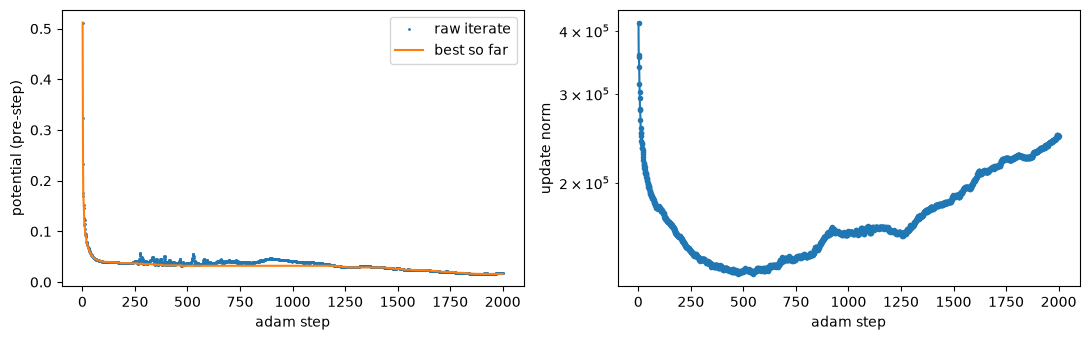

best objective = 131921.432009   raw end-iterate objective = 248063.292004


In [7]:
hist = np.asarray([losses, unorms])  # row 0: update norm, row 1: objective at the start of each step
steps = np.arange(1, MAP_MAX_ITER + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(steps, hist[1], ".", ms=2, label="raw iterate")
ax1.plot(steps, np.minimum.accumulate(hist[1]), "-", label="best so far")
ax1.set_xlabel("adam step")
ax1.set_ylabel("potential (pre-step)")
ax1.legend()
ax2.plot(steps, hist[0], ".-")
ax2.set_xlabel("adam step")
ax2.set_ylabel("update norm")
ax2.set_yscale("log")
plt.tight_layout()
plt.show()
print(f"best objective = {best_f:.6f}   raw end-iterate objective = {losses[-1]:.6f}")


## 8. Verify the saved reconstruction

Everything was written to parquet as it was produced — the truth and init stages in sections 3–4 as single files, and one density-lightcone + kappa parquet per minimizer run under `density_evolution/` and `kappa_evolution/`. The files are read back here and visualized: a kappa filmstrip over all reconstruction stages, and a truth-vs-final comparison of the density lightcone.

In [8]:
from pathlib import Path

out = Path(OUT_DIR)

# Static stages: single parquet each.
static = {
    name: jfli.io.Catalog.from_parquet(str(out / f"{name}.parquet"))
    for name in ("true_ic", "init_ic", "truth_density_lightcone", "truth_kappa")
}
for name, cat in static.items():
    field = cat.field[0]
    print(
        f"{name}.parquet: {len(cat)} row(s)  {type(field).__name__}  {np.asarray(field.array).shape}"
        f"  status={field.status.name}  Omega_c={float(cat.cosmology[0].Omega_c):.4f}"
        f"  sigma8={float(cat.cosmology[0].sigma8):.4f}"
    )

# Evolution: one parquet per animation frame (frame 0 = warm start), sorted by numeric index.
ic_files = sorted((out / "ic_evolution").glob("ic_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
lc_files = sorted((out / "density_evolution").glob("lc_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
kappa_files = sorted((out / "kappa_evolution").glob("kappa_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
assert len(ic_files) == len(lc_files) == len(kappa_files) == N_SNAPSHOTS + 1, (
    f"{len(lc_files)} density / {len(kappa_files)} kappa / {len(ic_files)} IC frames != N_SNAPSHOTS + 1 = {N_SNAPSHOTS + 1}"
)
ic_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in ic_files]
lc_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in lc_files]
kappa_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in kappa_files]
for files, cats in ((ic_files, ic_snaps), (lc_files, lc_snaps), (kappa_files, kappa_snaps)):
    for path, cat in zip(files, cats):
        field = cat.field[0]
        print(
            f"{path.relative_to(out)}: {len(cat)} row(s)  {type(field).__name__}  {np.asarray(field.array).shape}"
            f"  status={field.status.name}  Omega_c={float(cat.cosmology[0].Omega_c):.4f}"
            f"  sigma8={float(cat.cosmology[0].sigma8):.4f}"
        )
print("all saved fields read back OK")

truth_lc_field = static["truth_density_lightcone"].field[0]
truth_kappa_field = static["truth_kappa"].field[0]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

true_ic.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
init_ic.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
truth_density_lightcone.parquet: 1 row(s)  SphericalDensity  (5, 49152)  status=LIGHTCONE  Omega_c=0.1322  sigma8=0.8685
truth_kappa.parquet: 1 row(s)  SphericalKappaField  (2, 49152)  status=KAPPA  Omega_c=0.1322  sigma8=0.8685


...

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

ic_evolution/ic_0.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
ic_evolution/ic_1.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
ic_evolution/ic_2.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
ic_evolution/ic_3.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
ic_evolution/ic_4.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
ic_evolution/ic_5.parquet: 1 row(s)  DensityField  (64, 64, 64)  status=INITIAL_FIELD  Omega_c=0.1322  sigma8=0.8685
density_evolution/lc_0.parquet: 1 row(s)  SphericalDensity  (5, 49152)  status=LIGHTCONE  Omega_c=0.1322  sigma8=0.8685
density_evolution/lc_1.parquet: 1 row(s)  SphericalDensity  (5, 49152)  status=LIGHTCONE  Omega_c=0.1322  sigma8=0.8685
density_evolution/lc_2.parquet: 1 row(s)  SphericalDensity

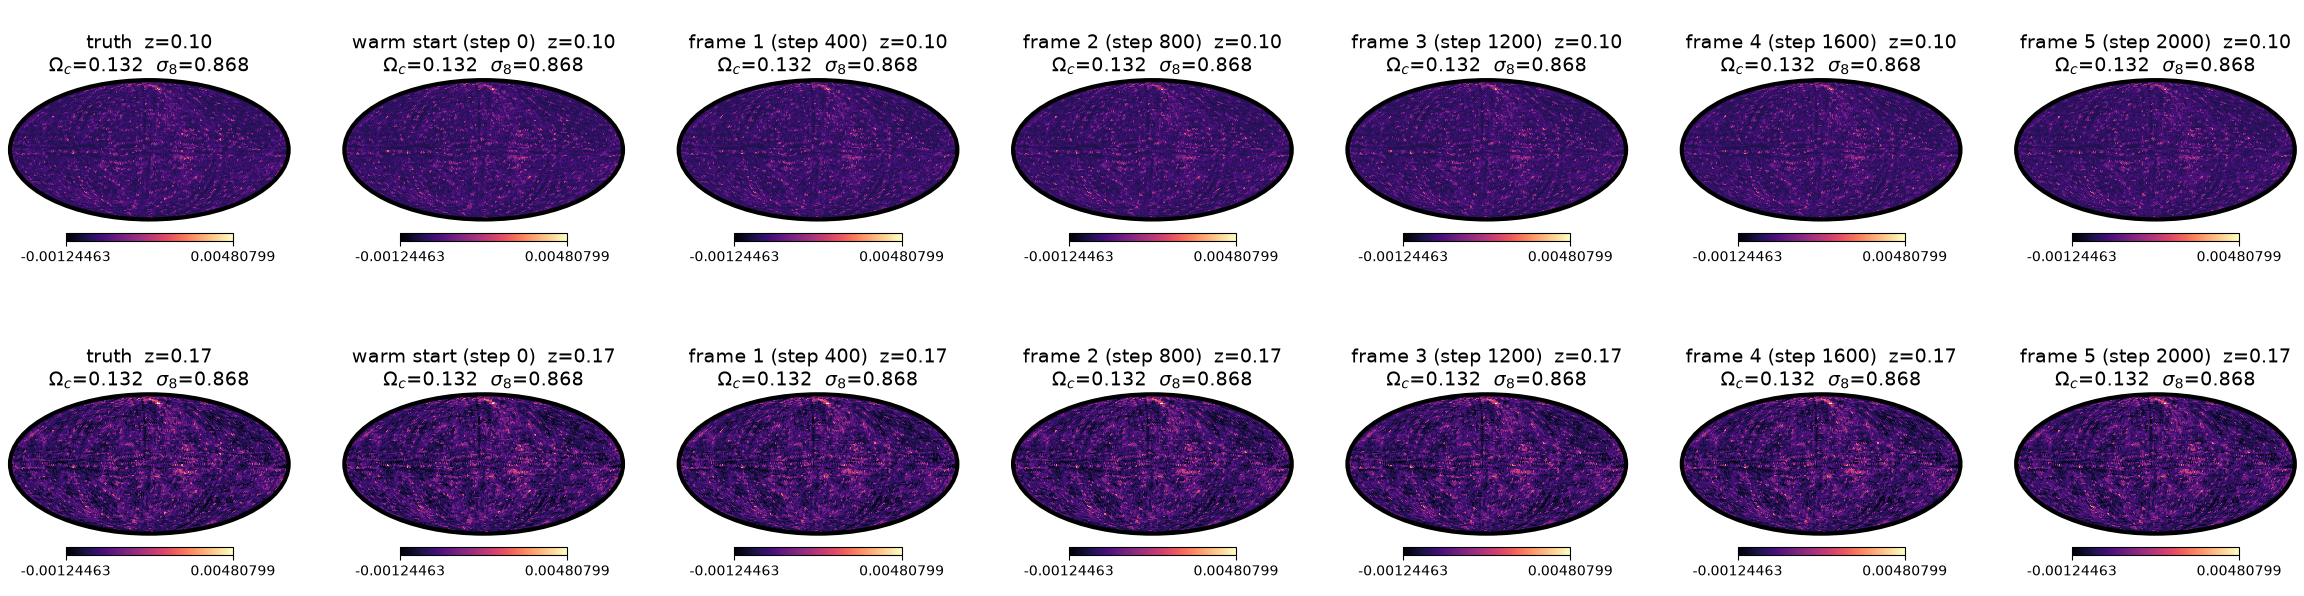

In [9]:
# Kappa filmstrip: columns = truth + one per minimizer run, rows = source planes, shared color scale.
kappa_fields = [truth_kappa_field] + [cat.field[0] for cat in kappa_snaps]
frame_steps = np.linspace(0, MAP_MAX_ITER, N_SNAPSHOTS + 1).astype(int)
stages = [("truth", static["truth_kappa"].cosmology[0])] + [
    (f"frame {r} (step {frame_steps[r]})" if r else "warm start (step 0)", cat.cosmology[0])
    for r, cat in enumerate(kappa_snaps)
]
vals = np.concatenate([np.asarray(f.array).ravel() for f in kappa_fields])
vmin, vmax = float(vals.min()), float(vals.max())

zs = np.asarray(truth_kappa_field.z_sources)
fig, axes = plt.subplots(len(zs), len(kappa_fields), figsize=(3.4 * len(kappa_fields), 3.2 * len(zs)), squeeze=False)
for c, ((label, cos), field) in enumerate(zip(stages, kappa_fields)):
    par = f"$\\Omega_c$={float(cos.Omega_c):.3f}  $\\sigma_8$={float(cos.sigma8):.3f}"
    field.plot(
        ax=list(axes[:, c]),
        titles=[f"{label}  z={float(z):.2f}\n{par}" for z in zs],
        vmin=vmin,
        vmax=vmax,
    )
plt.show()

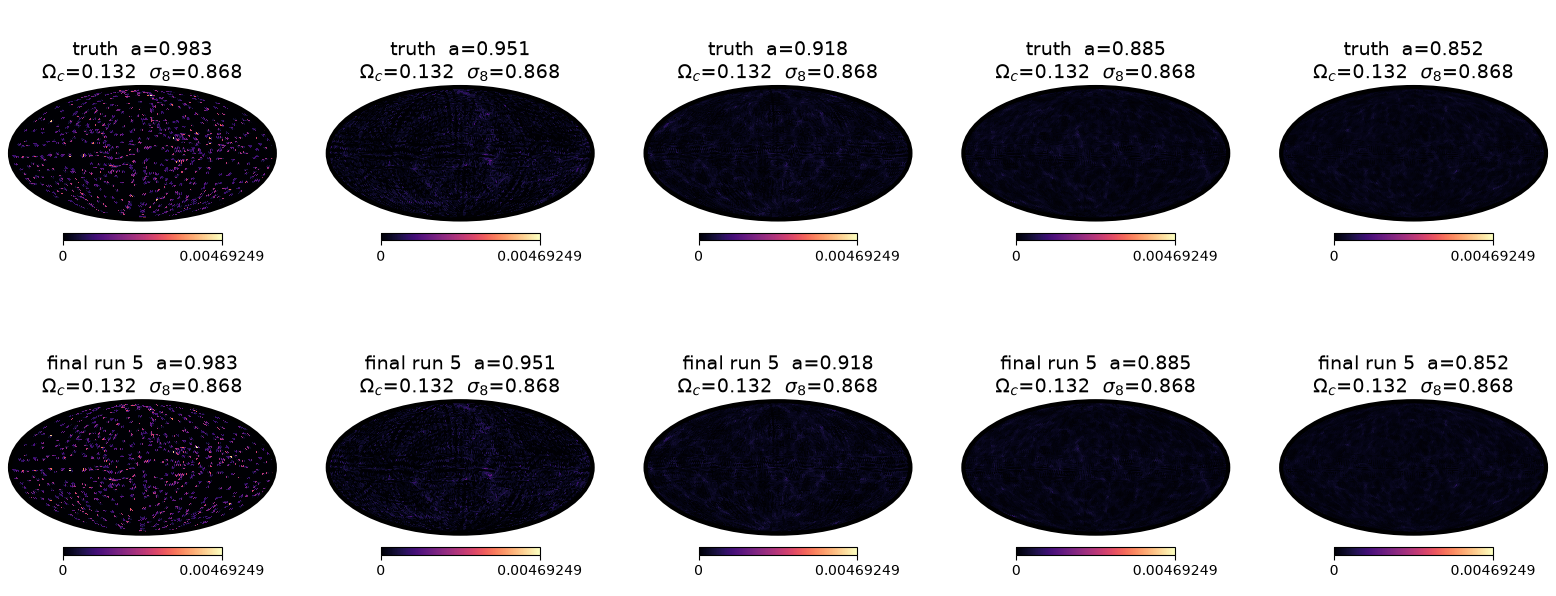

In [10]:
# Density lightcone: truth vs final snapshot, one column per shell, shared color scale.
lc_fields = [truth_lc_field, lc_snaps[-1].field[0]]
stages = [
    ("truth", static["truth_density_lightcone"].cosmology[0]),
    (f"final run {len(lc_snaps) - 1}", lc_snaps[-1].cosmology[0]),
]
vals = np.concatenate([np.asarray(f.array).ravel() for f in lc_fields])
assert np.all(np.isfinite(vals)), f"density lightcone has {np.count_nonzero(~np.isfinite(vals))} non-finite values"
vmin, vmax = float(vals.min()), float(vals.max())

n_shells = int(np.asarray(truth_lc_field.array).shape[0])
fig, axes = plt.subplots(2, n_shells, figsize=(3.2 * n_shells, 6.4), squeeze=False)
for r, ((label, cos), field) in enumerate(zip(stages, lc_fields)):
    par = f"$\\Omega_c$={float(cos.Omega_c):.3f}  $\\sigma_8$={float(cos.sigma8):.3f}"
    field.plot(
        ax=list(axes[r]),
        titles=[f"{label}  a={float(a):.3f}\n{par}" for a in field.scale_factors],
        vmin=vmin,
        vmax=vmax,
    )
plt.show()

## 9. Uncertainty: Hessian of the conditioned potential

Conditioning **additionally** on the IC field at its MAP value leaves only the two base cosmology parameters free, so the Hessian of that potential is a cheap 2×2. This is a *conditional* covariance (IC fixed at the MAP), not the marginal over the field — marginalizing the field needs matrix-free curvature or MUSE. If second-order AD breaks through `jax_cosmo`'s custom VJPs, we fall back to central finite differences of the gradient (4 gradient evals for 2 parameters).

In [11]:
if OPTIMIZE == "ic":
    uq_skip = True
    print("OPTIMIZE='ic': cosmology is fixed, the conditional 2x2 cosmology Hessian is undefined — skipping UQ.")
else:
    uq_skip = False
    cond_ic = condition(
        model,
        data={
            "observable_0": x_obs[0],
            "observable_1": x_obs[1],
            "initial_conditions": map_params.get("initial_conditions", ic_init_white),
        },
    )
    _, pot2_fn, _, _ = initialize_model(jax.random.PRNGKey(0), cond_ic, dynamic_args=False)

    def pot2(theta_base):
        return pot2_fn({"Omega_c_base": theta_base[0], "sigma8_base": theta_base[1]})

    theta0 = jnp.array([float(map_params["Omega_c_base"]), float(map_params["sigma8_base"])])

    # Hessian via reverse-mode autodiff twice (jacrev of grad)
    # custom_vjp functions don't support forward-mode jvp, so we avoid jax.hessian
    H = jax.jacrev(jax.grad(pot2))(theta0)
    uq_method = "jax.jacrev(jax.grad)"

    H = (H + H.T) / 2  # ensure symmetry
    cov_base = jnp.linalg.inv(H)
    sd_base = jnp.sqrt(jnp.diag(cov_base))
    rho = float(cov_base[0, 1] / (sd_base[0] * sd_base[1]))

    # base-space sigma -> physical space through the probit Jacobian d(phys)/d(base); rho is invariant.
    jacobian = (HIGH - LOW) * jnp.exp(-0.5 * theta0**2) / jnp.sqrt(2 * jnp.pi)
    sd_phys = jacobian * sd_base
    print(f"UQ via {uq_method}:")
    print(f"  sigma(Omega_c) = {float(sd_phys[0]):.3e}   sigma(sigma8) = {float(sd_phys[1]):.3e}   rho = {rho:.3f}")

OPTIMIZE='ic': cosmology is fixed, the conditional 2x2 cosmology Hessian is undefined — skipping UQ.


In [12]:
if not uq_skip:
    # Sanity check: exact 2D posterior on a small grid around the MAP (cheap forward evals at this
    # mesh), with the Laplace ellipse mapped through the probit on top. If the red curve tracks the
    # blue contours, the base-space Gaussian is a fair local approximation.
    n_grid = 21
    gx = float(theta_map[0]) + np.linspace(-4 * float(sd_phys[0]), 4 * float(sd_phys[0]), n_grid)
    gy = float(theta_map[1]) + np.linspace(-4 * float(sd_phys[1]), 4 * float(sd_phys[1]), n_grid)
    GX, GY = np.meshgrid(gx, gy)
    pts = jnp.clip(jnp.asarray(np.stack([GX.ravel(), GY.ravel()], -1)), LOW, HIGH)
    nll = np.asarray(jax.lax.map(lambda th: pot2(base_of_phys(th)), pts)).reshape(n_grid, n_grid)
    nll = nll - nll.min()

    t = np.linspace(0, 2 * np.pi, 120)
    evals, evecs = np.linalg.eigh(np.asarray(cov_base))
    ell_base = theta0[:, None] + evecs @ (
        np.sqrt(np.clip(5.991 * evals, 0.0, None))[:, None] * np.stack([np.cos(t), np.sin(t)], 0)
    )
    ell_phys = np.asarray(phys_of_base(ell_base.T))

    fig, ax = plt.subplots(figsize=(6.2, 5))
    ax.contourf(GX, GY, np.exp(-nll), 30, cmap="Blues")
    ax.plot(ell_phys[:, 0], ell_phys[:, 1], "r-", lw=2, label="Laplace 95%")
    ax.plot(float(theta_map[0]), float(theta_map[1]), "r*", ms=12, label="MAP")
    ax.plot(float(theta_truth[0]), float(theta_truth[1]), "k+", ms=12, mew=2, label="truth")
    ax.set_xlabel(r"$\Omega_c$")
    ax.set_ylabel(r"$\sigma_8$")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Truth IC vs predicted IC

The MAP `initial_conditions` site is the *white* field; colouring it at the MAP cosmology gives the physical predicted IC, directly comparable with the truth IC from section 3.

IC recovery: MSE(truth, MAP) = 1.958e-03


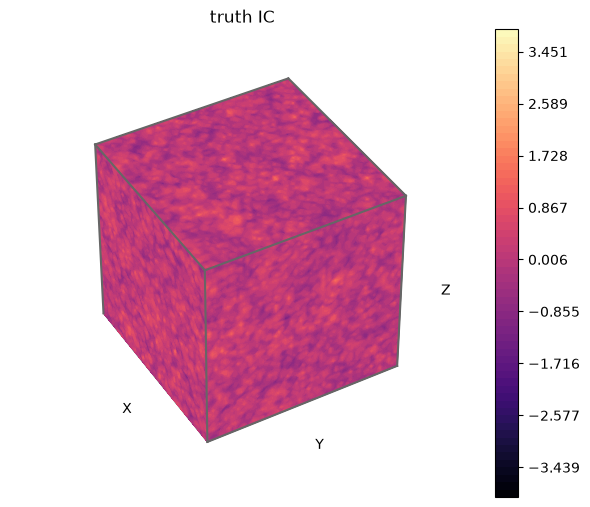

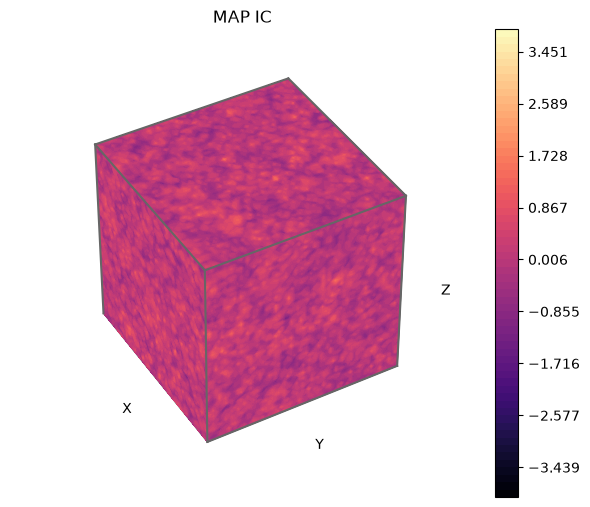

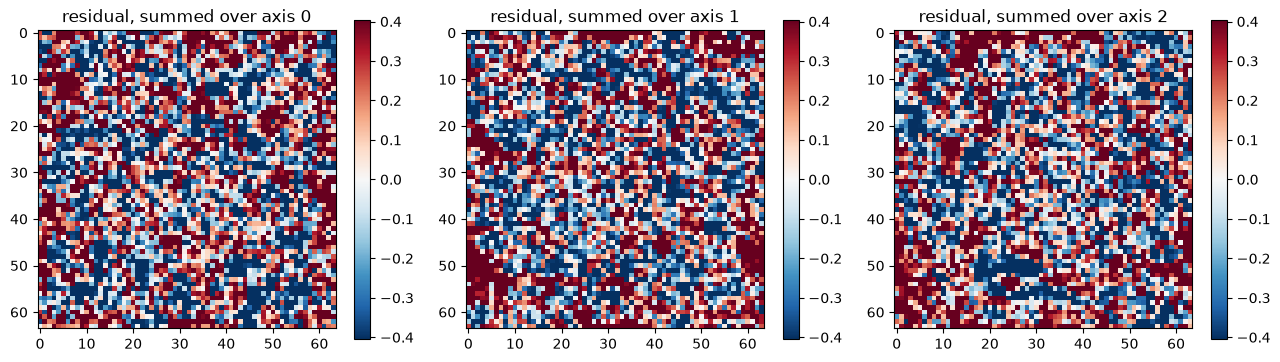

In [13]:
cosmo_map = config.fiducial_cosmology(Omega_c=float(theta_map[0]), sigma8=float(theta_map[1]))
ic_map = interpolate_initial_conditions(
    map_params.get("initial_conditions", ic_init_white),
    config.mesh_size,
    config.box_size,
    cosmo=cosmo_map,
    observer_position=config.observer_position,
    halo_size=config.halo_size,
    nside=config.nside,
    field_sharding=config.field_sharding,
)

vmin = float(min(ic_truth.array.min(), ic_map.array.min()))
vmax = float(max(ic_truth.array.max(), ic_map.array.max()))
print(f"IC recovery: MSE(truth, MAP) = {float(((ic_truth.array - ic_map.array) ** 2).mean()):.3e}")

ic_truth.show(titles="truth IC", vmin=vmin, vmax=vmax)
ic_map.show(titles="MAP IC", vmin=vmin, vmax=vmax)

resid = np.asarray(ic_truth.array - ic_map.array)
m = float(np.abs(resid).max())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for k, ax in enumerate(axes):
    im = ax.imshow(resid.sum(axis=k), cmap="RdBu_r", vmin=-m, vmax=m)
    ax.set_title(f"residual, summed over axis {k}")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

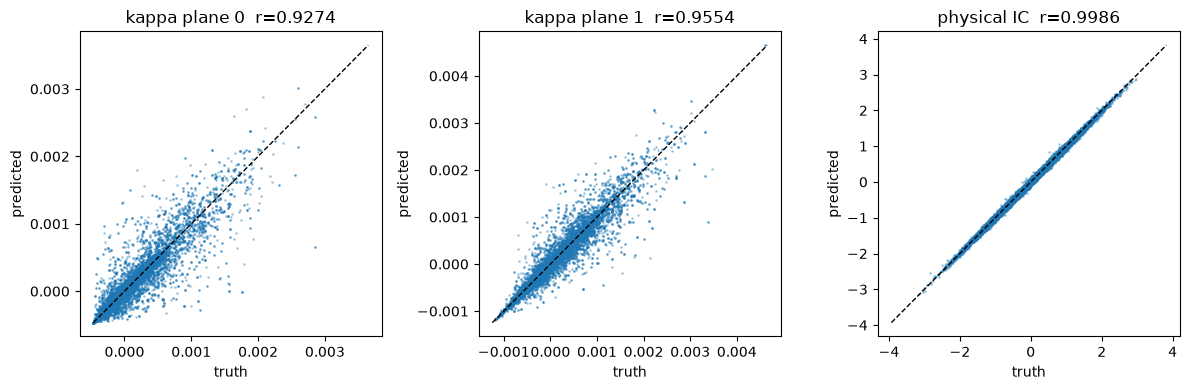

In [14]:
# Predicted vs truth at the MAP: pixel scatter for both kappa planes and the physical IC.
# Points on the diagonal mean the reconstruction reproduces the truth; r is printed per panel.
rng = np.random.default_rng(0)
panels = [
    ("kappa plane 0", np.asarray(truth_kappa_field.array[0]), np.asarray(kappa_snaps[-1].field[0].array[0])),
    ("kappa plane 1", np.asarray(truth_kappa_field.array[1]), np.asarray(kappa_snaps[-1].field[0].array[1])),
    ("physical IC", np.asarray(ic_truth.array).ravel(), np.asarray(ic_map.array).ravel()),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, true, pred) in zip(axes, panels):
    t, p = true.ravel(), pred.ravel()
    idx = rng.choice(t.size, size=min(20000, t.size), replace=False)
    ax.scatter(t[idx], p[idx], s=1, alpha=0.3)
    lims = [float(min(t.min(), p.min())), float(max(t.max(), p.max()))]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{title}  r={float(np.corrcoef(t, p)[0, 1]):.4f}")
    ax.set_xlabel("truth")
    ax.set_ylabel("predicted")
plt.tight_layout()
plt.show()